# Hackathon de Ciência de Dados — O Desafio de 1936

Este notebook analisa o erro da pesquisa eleitoral realizada pela **The Literary Digest** na eleição presidencial dos Estados Unidos de 1936.

A proposta não é apenas mostrar que a pesquisa errou, mas tentar responder uma pergunta de ciência de dados: **é possível usar informações históricas da própria amostra para detectar parte do viés e construir uma correção simples?**

O fluxo da análise é:

1. carregar as planilhas históricas;
2. limpar e organizar os dados relevantes;
3. calcular proporções comparáveis entre amostra e resultado real;
4. usar o voto declarado de 1932 como uma espécie de **âncora histórica**;
5. medir o viés da amostra;
6. ajustar uma **Regressão Linear** com Scikit-Learn;
7. aplicar essa correção à pesquisa de 1936;
8. avaliar o resultado com métricas de erro e projeção de vencedores.

### Por que essa abordagem faz sentido?

A pesquisa de 1936 também registrou como os entrevistados disseram ter votado em 1932. Como o resultado real de 1932 é conhecido, podemos comparar a composição política da amostra com a composição real daquela eleição. Se a amostra de 1936 estiver muito mais republicana do que o eleitorado real de 1932, isso é um indício de **desequilíbrio amostral**.

A regressão linear foi escolhida porque é um método simples, interpretável e suficiente para testar uma relação de calibração entre duas proporções. O objetivo aqui não é criar um modelo complexo, mas construir uma correção que possa ser explicada e defendida.

### Bibliotecas utilizadas

- **Pandas:** leitura e manipulação das tabelas;
- **NumPy:** operações numéricas;
- **Matplotlib:** gráficos;
- **Scikit-Learn:** regressão linear e métricas de avaliação.


In [3]:
# =============================
# IMPORTAÇÃO DAS BIBLIOTECAS
# =============================

# Path facilita procurar o arquivo da base de dados dentro da pasta do notebook.
from pathlib import Path

# O módulo os é usado apenas para definir uma pasta temporária de configuração do Matplotlib.
import os

# Define uma pasta de configuração gravável para o Matplotlib.
# Isso evita problemas de permissão em ambientes como Kaggle, Colab ou servidores.
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

# NumPy será usado em cálculos numéricos e para limitar proporções entre 0 e 1.
import numpy as np

# Pandas é a principal biblioteca usada para organizar e tratar os dados em tabelas.
import pandas as pd

# Matplotlib será usado para criar os gráficos da análise.
import matplotlib.pyplot as plt

# LinearRegression implementa a regressão linear utilizada como modelo de calibração.
from sklearn.linear_model import LinearRegression

# As métricas permitem avaliar numericamente a qualidade da correção.
# MAE = erro absoluto médio.
# MSE = erro quadrático médio, usado depois para calcular o RMSE.
# R² = mede quanto da variação de y é explicada pela regressão no ajuste de 1932.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mostra até 100 colunas quando um DataFrame for exibido.
# Isso evita que informações importantes sejam ocultadas com "...".
pd.set_option("display.max_columns", 100)

# Padroniza a exibição dos números decimais com quatro casas.
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 1. Carregamento do arquivo

O arquivo `LitDigestFull.xlsx` contém abas referentes a diferentes eleições. Para esta análise, são necessárias principalmente as abas **1932** e **1936**.

A planilha original não tem o formato de uma base de dados moderna: existem cabeçalhos em várias linhas e diferentes blocos de informação lado a lado. Por esse motivo, a leitura é feita inicialmente com `header=None`.

**Justificativa:** ler os dados sem cabeçalho evita que o Pandas escolha automaticamente uma linha incorreta como nome das colunas. Depois disso, selecionamos manualmente apenas as colunas necessárias para a análise.


In [4]:
# Procura o arquivo LitDigestFull.xlsx na pasta atual e também em subpastas.
# Isso torna o notebook mais portátil: ele funciona tanto localmente quanto em ambientes como Kaggle,
# desde que o arquivo tenha sido adicionado ao projeto.
arquivos = list(Path(".").rglob("LitDigestFull.xlsx"))

# Se a lista estiver vazia, significa que o arquivo não foi encontrado.
# Em vez de deixar o código falhar mais adiante com um erro pouco claro,
# geramos uma mensagem explicando exatamente o que está faltando.
if not arquivos:
    raise FileNotFoundError(
        "O arquivo LitDigestFull.xlsx não foi encontrado. "
        "Coloque o arquivo na mesma pasta do notebook ou adicione-o ao ambiente."
    )

# Como o nome do arquivo é específico, usamos o primeiro resultado encontrado.
ARQUIVO = arquivos[0]
print("Arquivo encontrado:", ARQUIVO)

# ExcelFile permite inspecionar as abas disponíveis antes de carregá-las.
xls = pd.ExcelFile(ARQUIVO)
print("Abas disponíveis:", xls.sheet_names)

# Carregamos as abas de 1932 e 1936 sem assumir uma linha de cabeçalho.
# Isso é necessário porque a planilha original possui uma estrutura irregular.
raw_1932 = pd.read_excel(ARQUIVO, sheet_name="1932", header=None)
raw_1936 = pd.read_excel(ARQUIVO, sheet_name="1936", header=None)

# Conferimos as dimensões para validar que os dados foram carregados.
print("Dimensão da aba 1932:", raw_1932.shape)
print("Dimensão da aba 1936:", raw_1936.shape)


Arquivo encontrado: LitDigestFull.xlsx
Abas disponíveis: ['1924', '1928', '1932', '1936']
Dimensão da aba 1932: (53, 45)
Dimensão da aba 1936: (52, 56)


## 2. Limpeza e preparação dos dados

Na aba de 1936 existem dois blocos que interessam para o trabalho:

1. os resultados da pesquisa da **Literary Digest**;
2. os resultados reais da eleição de 1936.

Também existem colunas que registram como os entrevistados de 1936 disseram ter votado em 1932. Essa informação é especialmente importante porque permite comparar **a composição política da amostra** com **o resultado real da eleição anterior**.

### Por que selecionar apenas algumas colunas?

A planilha contém muitas informações que não são necessárias para responder ao problema proposto. Trabalhar somente com as colunas relevantes deixa o código mais simples, reduz a chance de erro e facilita a interpretação.

### Por que remover totais e linhas desconhecidas?

O modelo trabalha no nível dos estados. Linhas como `Totals`, `TOTALS` e `State Unknown` não representam observações estaduais comparáveis e, portanto, não devem entrar nos cálculos.


In [5]:
# ======================================
# BLOCO DA PESQUISA LITERARY DIGEST - 1936
# ======================================

# Na planilha original, cada informação está em uma posição específica.
# Os índices abaixo correspondem às seguintes colunas do Excel:
# A  = Estado
# B  = Votos eleitorais
# C  = Votos para Landon na pesquisa
# D/E  = Entre os eleitores de Landon, voto Rep./Dem. declarado em 1932
# K  = Votos para Roosevelt na pesquisa
# L/M  = Entre os eleitores de Roosevelt, voto Rep./Dem. declarado em 1932
# S  = Votos para Lemke na pesquisa
# T/U  = Entre os eleitores de Lemke, voto Rep./Dem. declarado em 1932
# AG = Total de respostas no estado

# A partir da terceira linha (índice 2), selecionamos apenas as colunas necessárias.
# .copy() cria um DataFrame independente e evita alterações acidentais na tabela original.
ld36 = raw_1936.iloc[2:, [0, 1, 2, 3, 4, 10, 11, 12, 18, 19, 20, 32]].copy()

# Renomeamos as colunas com nomes descritivos para tornar o restante do código legível.
ld36.columns = [
    "state",
    "electoral_votes_poll",
    "landon_poll",
    "landon_1932_rep",
    "landon_1932_dem",
    "roosevelt_poll",
    "roosevelt_1932_rep",
    "roosevelt_1932_dem",
    "lemke_poll",
    "lemke_1932_rep",
    "lemke_1932_dem",
    "poll_total"
]

# Converte a coluna do estado para texto e remove espaços extras nas extremidades.
# Isso evita problemas na hora de juntar tabelas pelo nome do estado.
ld36["state"] = ld36["state"].astype(str).str.strip()

# Remove linhas agregadas ou sem identificação de estado.
# O modelo deve trabalhar apenas com os estados individualmente.
ld36 = ld36[~ld36["state"].isin(["State Unknown", "Totals", "nan"])].copy()

# Todas as colunas, exceto "state", deveriam ser numéricas.
# A lista abaixo identifica automaticamente essas colunas.
num_cols_ld36 = [c for c in ld36.columns if c != "state"]

# Converte os valores para números.
# errors="coerce" transforma valores inválidos em NaN, permitindo identificar problemas sem interromper o código.
ld36[num_cols_ld36] = ld36[num_cols_ld36].apply(pd.to_numeric, errors="coerce")

# Conferimos quantos estados permaneceram após a limpeza.
print("Estados válidos na pesquisa de 1936:", len(ld36))

# Exibe as primeiras linhas para validar visualmente a estrutura criada.
ld36.head()


Estados válidos na pesquisa de 1936: 48


,state,electoral_votes_poll,landon_poll,landon_1932_rep,landon_1932_dem,roosevelt_poll,roosevelt_1932_rep,roosevelt_1932_dem,lemke_poll,lemke_1932_rep,lemke_1932_dem,poll_total
2,Alabama,11,3060,1218,1298,10082,371,8530,68,5,49,13273
3,Arizona,3,2337,1431,647,1975,248,1555,104,22,52,4476
4,Arkansas,9,2724,1338,953,7608,228,6655,138,14,98,10540
5,California,22,89516,65360,16200,77245,15165,53520,4977,1620,2560,173935
6,Colorado,6,15949,11872,2714,10025,1747,7256,579,136,333,26786


In [6]:
# =============================
# RESULTADO REAL DA ELEIÇÃO - 1936
# =============================

# No segundo bloco da planilha de 1936, usamos:
# AI = Estado
# AJ = Votos eleitorais
# AK = Votos reais de Roosevelt
# AN = Votos reais de Landon
# BB = Total de votos

# Seleciona as colunas do resultado oficial.
actual36 = raw_1936.iloc[1:, [34, 35, 36, 39, 53]].copy()

# Renomeia as colunas com nomes mais fáceis de interpretar.
actual36.columns = [
    "state",
    "electoral_votes",
    "roosevelt_actual",
    "landon_actual",
    "actual_total"
]

# Padroniza os nomes dos estados como texto sem espaços extras.
actual36["state"] = actual36["state"].astype(str).str.strip()

# Remove linhas de totalização e linhas vazias.
# Esses registros não representam um estado e atrapalhariam a junção posterior.
actual36 = actual36[
    (~actual36["state"].str.startswith("TOTALS", na=False)) &
    (actual36["state"] != "nan")
].copy()

# Converte as colunas numéricas individualmente.
# Novamente, errors="coerce" impede que textos ou células vazias quebrem a execução.
for c in ["electoral_votes", "roosevelt_actual", "landon_actual", "actual_total"]:
    actual36[c] = pd.to_numeric(actual36[c], errors="coerce")

# Mantemos somente estados que possuem os votos reais dos dois principais candidatos.
# Sem esses dois valores, não é possível calcular a proporção republicana real de 1936.
actual36 = actual36.dropna(subset=["roosevelt_actual", "landon_actual"]).copy()

# Verificação final da quantidade de estados e das primeiras linhas.
print("Estados com resultado real de 1936:", len(actual36))
actual36.head()


Estados com resultado real de 1936: 48


,state,electoral_votes,roosevelt_actual,landon_actual,actual_total
1,Alabama,11,238136,35358,275244
2,Arizona,3,86722,33433,124163
3,Arkansas,9,146765,32039,179423
4,California,22,1766836,836431,2638882
5,Colorado,6,295021,181267,488684


In [7]:
# =============================
# RESULTADO REAL DA ELEIÇÃO - 1932
# =============================

# Na aba de 1932, usamos:
# AB = Estado
# AD = Votos reais de Roosevelt
# AG = Votos reais de Hoover

# Seleciona as colunas necessárias do resultado oficial de 1932.
actual32 = raw_1932.iloc[1:, [27, 29, 32]].copy()

# Renomeia as colunas para facilitar a leitura do código.
actual32.columns = ["state", "roosevelt_actual_1932", "hoover_actual_1932"]

# Padroniza o nome dos estados como texto e remove espaços extras.
actual32["state"] = actual32["state"].astype(str).str.strip()

# Remove a linha de total e linhas vazias.
actual32 = actual32[
    (actual32["state"] != "Total") &
    (actual32["state"] != "nan")
].copy()

# Converte os votos de Roosevelt para formato numérico.
actual32["roosevelt_actual_1932"] = pd.to_numeric(
    actual32["roosevelt_actual_1932"], errors="coerce"
)

# Converte os votos de Hoover para formato numérico.
actual32["hoover_actual_1932"] = pd.to_numeric(
    actual32["hoover_actual_1932"], errors="coerce"
)

# Mantemos apenas estados que possuem os resultados dos dois candidatos.
# Esses valores são necessários para calcular a proporção republicana real em 1932.
actual32 = actual32.dropna(
    subset=["roosevelt_actual_1932", "hoover_actual_1932"]
).copy()

# Conferência da quantidade de estados e das primeiras linhas.
print("Estados com resultado real de 1932:", len(actual32))
actual32.head()


Estados com resultado real de 1932: 48


,state,roosevelt_actual_1932,hoover_actual_1932
1,Alabama,207910,34675
2,Arizona,79264,36104
3,Arkansas,189602,28467
4,California,1324157,847902
5,Colorado,250877,189617


## 3. Construção das proporções

Para comparar estados de tamanhos diferentes, é melhor trabalhar com **proporções** em vez de números absolutos de votos.

A análise também utiliza uma comparação de **dois candidatos principais**:

### Eleição de 1936
- Republicano: **Alf Landon**
- Democrata: **Franklin D. Roosevelt**

### Eleição de 1932
- Republicano: **Herbert Hoover**
- Democrata: **Franklin D. Roosevelt**

### Por que usar a proporção entre os dois principais candidatos?

O objetivo é criar uma medida comparável entre 1932 e 1936. Como os candidatos menores possuem participações diferentes entre as eleições, trabalhar com a divisão Republicano × Democrata reduz esse problema e cria uma escala comum entre 0 e 1.

Isso é uma **simplificação metodológica**. Ela não significa que os votos de terceiros candidatos não existam; apenas permite construir uma calibração mais direta entre os dois grandes partidos.

### Como a composição retrospectiva de 1932 é reconstruída?

A pesquisa de 1936 registrou como seus respondentes afirmaram ter votado em 1932. Somamos essas respostas, independentemente de qual candidato a pessoa apoiava em 1936, e calculamos a proporção que declarou ter votado no republicano em 1932.

Essa proporção é comparada com o resultado republicano real de 1932 em cada estado.


In [8]:
# ======================================
# PROPORÇÕES E JUNÇÃO DAS BASES
# ======================================

# Calcula a proporção republicana observada pela Literary Digest em 1936.
# Consideramos apenas Landon e Roosevelt no denominador para manter a comparação bipartidária.
ld36["poll_rep_share_1936"] = (
    ld36["landon_poll"] /
    (ld36["landon_poll"] + ld36["roosevelt_poll"])
)

# Reconstrói quantos entrevistados disseram ter votado no republicano em 1932.
# Somamos essa informação entre os apoiadores de Landon, Roosevelt e Lemke em 1936.
# A intenção é medir a composição política anterior da amostra, não apenas de um grupo atual.
ld36["recalled_rep_1932"] = (
    ld36["landon_1932_rep"] +
    ld36["roosevelt_1932_rep"] +
    ld36["lemke_1932_rep"]
)

# Faz o mesmo para os entrevistados que disseram ter votado no democrata em 1932.
ld36["recalled_dem_1932"] = (
    ld36["landon_1932_dem"] +
    ld36["roosevelt_1932_dem"] +
    ld36["lemke_1932_dem"]
)

# Calcula a proporção republicana de 1932 DENTRO da amostra entrevistada em 1936.
# Essa é a variável usada para diagnosticar se a amostra estava mais republicana do que o eleitorado real.
ld36["sample_rep_share_1932"] = (
    ld36["recalled_rep_1932"] /
    (ld36["recalled_rep_1932"] + ld36["recalled_dem_1932"])
)

# Calcula a proporção republicana REAL de 1932.
# Hoover era o candidato republicano e Roosevelt o candidato democrata.
actual32["actual_rep_share_1932"] = (
    actual32["hoover_actual_1932"] /
    (actual32["hoover_actual_1932"] + actual32["roosevelt_actual_1932"])
)

# Calcula a proporção republicana REAL de 1936.
# Landon era o candidato republicano e Roosevelt o candidato democrata.
actual36["actual_rep_share_1936"] = (
    actual36["landon_actual"] /
    (actual36["landon_actual"] + actual36["roosevelt_actual"])
)

# Junta as três partes da análise pelo nome do estado:
# 1) pesquisa de 1936;
# 2) resultado real de 1932;
# 3) resultado real de 1936.
#
# O how="inner" mantém apenas estados presentes nas três fontes.
# Isso é importante porque as métricas precisam comparar exatamente o mesmo conjunto de estados.
df = (
    ld36
    .merge(
        actual32[["state", "actual_rep_share_1932"]],
        on="state",
        how="inner"
    )
    .merge(
        actual36[
            [
                "state",
                "electoral_votes",
                "actual_rep_share_1936",
                "landon_actual",
                "roosevelt_actual"
            ]
        ],
        on="state",
        how="inner"
    )
)

# Confere a quantidade de estados que realmente entrou na modelagem.
print("Estados usados no modelo:", len(df))

# Exibe as principais proporções lado a lado para uma checagem visual.
df[[
    "state",
    "sample_rep_share_1932",
    "actual_rep_share_1932",
    "poll_rep_share_1936",
    "actual_rep_share_1936"
]].head(10)


Estados usados no modelo: 48


,state,sample_rep_share_1932,actual_rep_share_1932,poll_rep_share_1936,actual_rep_share_1936
0,Alabama,0.1390,0.1429,0.2328,0.1293
1,Arizona,0.4301,0.3129,0.5420,0.2782
2,Arkansas,0.1701,0.1305,0.2636,0.1792
3,California,0.5319,0.3904,0.5368,0.3213
4,Colorado,0.5717,0.4305,0.6140,0.3806
5,Connecticut,0.6563,0.5060,0.6823,0.4217
6,Delaware,0.6276,0.5124,0.5876,0.4509
7,Florida,0.2944,0.2511,0.4139,0.2390
8,Georgia,0.1171,0.0782,0.2341,0.1264
9,Idaho,0.5289,0.3948,0.5832,0.3452


## 4. Diagnóstico do viés

A ideia central desta etapa é comparar duas medidas referentes a 1932:

- **`sample_rep_share_1932`**: proporção republicana de 1932 lembrada pelos participantes da pesquisa de 1936;
- **`actual_rep_share_1932`**: proporção republicana real da eleição de 1932.

Se a amostra fosse perfeitamente semelhante ao eleitorado real, essas duas proporções tenderiam a ficar próximas.

Definimos então:

**viés de 1932 = proporção republicana da amostra − proporção republicana real**

Quando esse valor é positivo, a amostra contém uma presença republicana maior do que a observada na eleição real de 1932.

### Limite dessa interpretação

Esse cálculo mostra um **desequilíbrio da amostra**, mas não permite separar exatamente quanto do problema veio de seleção da lista de contatos, não resposta, memória incorreta sobre 1932 ou outros fatores. Portanto, o notebook trata o resultado como evidência de viés amostral agregado, sem tentar atribuir causalidade a um único mecanismo.


In [9]:
# Calcula o viés republicano de 1932 em cada estado.
# Valor positivo = amostra mais republicana que o resultado real.
# Valor negativo = amostra menos republicana que o resultado real.
df["bias_1932"] = df["sample_rep_share_1932"] - df["actual_rep_share_1932"]

# A média do viés estadual oferece uma visão geral da direção do desequilíbrio.
# Multiplicamos por 100 apenas na apresentação para converter a proporção em pontos percentuais.
print("Viés médio republicano observado na amostra:")
print(f"{df['bias_1932'].mean() * 100:.2f} pontos percentuais")

# Mostra os 10 estados com maior viés republicano.
# A tabela é útil para verificar se o problema está concentrado em poucos estados
# ou aparece de forma relevante em várias unidades.
print("\nResumo do viés por estado:")
display(
    df[["state", "bias_1932"]]
    .assign(bias_1932=lambda x: x["bias_1932"] * 100)
    .sort_values("bias_1932", ascending=False)
    .head(10)
)


Viés médio republicano observado na amostra:
9.69 pontos percentuais

Resumo do viés por estado:


,state,bias_1932
36,Rhode Island,23.5216
18,Massachusetts,23.0938
26,New Hampshire,20.2844
38,South Dakota,17.8515
46,Wisconsin,16.4323
23,Montana,15.9775
31,North Dakota,15.8156
19,Michigan,15.1934
5,Connecticut,15.0338
27,New Jersey,14.9437


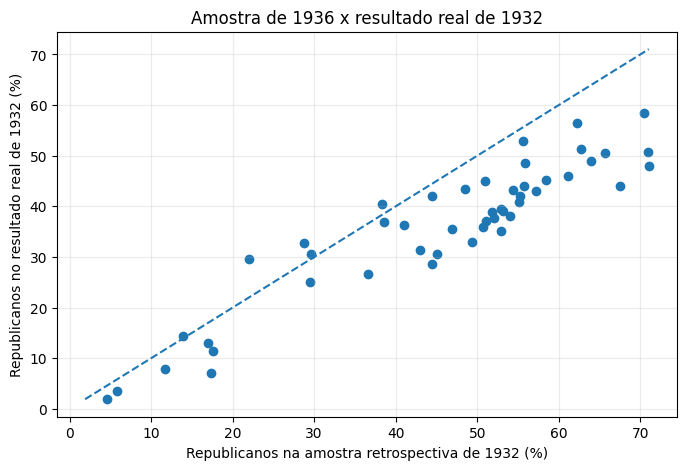

In [10]:
# Cria uma figura com tamanho suficiente para leitura dos pontos.
plt.figure(figsize=(8, 5))

# Cada ponto representa um estado.
# Eixo X: composição republicana retrospectiva dentro da amostra de 1936.
# Eixo Y: composição republicana real da eleição de 1932.
plt.scatter(
    df["sample_rep_share_1932"] * 100,
    df["actual_rep_share_1932"] * 100
)

# Determina o menor valor observado entre os dois eixos.
# Ele será usado para desenhar a linha de referência y = x.
min_v = min(
    df["sample_rep_share_1932"].min(),
    df["actual_rep_share_1932"].min()
) * 100

# Determina o maior valor observado entre os dois eixos.
max_v = max(
    df["sample_rep_share_1932"].max(),
    df["actual_rep_share_1932"].max()
) * 100

# Linha tracejada de referência y = x.
# Se um ponto estivesse exatamente sobre essa linha, a composição da amostra
# seria igual ao resultado real de 1932 naquele estado.
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

# Rótulos deixam claro o significado dos dois eixos.
plt.xlabel("Republicanos na amostra retrospectiva de 1932 (%)")
plt.ylabel("Republicanos no resultado real de 1932 (%)")

# Título resume a comparação apresentada.
plt.title("Amostra de 1936 x resultado real de 1932")

# A grade ajuda a comparar visualmente as posições dos pontos.
plt.grid(alpha=0.25)

# Exibe o gráfico.
plt.show()


## 5. Modelo de correção com Regressão Linear

Nesta etapa, usamos uma **Regressão Linear simples** para aprender a relação entre:

- **X:** proporção republicana de 1932 observada dentro da amostra da Literary Digest;
- **y:** proporção republicana real da eleição de 1932.

Em termos práticos, o modelo aprende uma equação do tipo:

**proporção corrigida = intercepto + coeficiente × proporção observada**

### Por que usar regressão linear?

1. O problema envolve duas variáveis numéricas contínuas em forma de proporção.
2. Queremos uma transformação simples e interpretável.
3. O objetivo do trabalho é mostrar uma estratégia de **calibração**, não maximizar a complexidade preditiva.
4. A equação final pode ser explicada diretamente no relatório e no pôster.

### Por que treinar com 1932 e aplicar em 1936?

O resultado real de 1932 é conhecido e funciona como referência para medir o desequilíbrio da amostra. A hipótese de trabalho é que parte desse padrão de sobre-representação também afeta a pesquisa de 1936. Assim, usamos a relação observada em 1932 como uma regra de correção aplicada à proporção bruta de 1936.

### Limitação importante

Essa é uma hipótese de calibração. O modelo não prova que o comportamento do viés foi idêntico entre 1932 e 1936. A validade da correção é avaliada depois, comparando a previsão corrigida com o resultado real de 1936.


In [11]:
# X contém a proporção republicana de 1932 observada dentro da amostra de 1936.
# O Scikit-Learn espera que X seja uma matriz 2D, por isso usamos duas chaves [[...]].
X = df[["sample_rep_share_1932"]].to_numpy()

# y contém a proporção republicana REAL de 1932, que funciona como valor-alvo da calibração.
y = df["actual_rep_share_1932"].to_numpy()

# Cria o modelo de regressão linear simples.
# Não utilizamos parâmetros adicionais porque queremos uma relação linear básica e interpretável.
modelo = LinearRegression()

# Ajusta a reta que melhor relaciona a composição da amostra de 1932 com o resultado real de 1932.
modelo.fit(X, y)

# Gera previsões sobre os próprios dados de 1932.
# Essas previsões são usadas apenas para avaliar quão bem a relação linear descreve a calibração histórica.
pred_1932 = modelo.predict(X)

# Exibe a equação estimada pelo modelo.
# O intercepto representa o ponto de partida da reta.
# O coeficiente representa o quanto a saída muda para cada unidade de mudança na proporção observada.
print("Equação aproximada da correção:")
print(
    f"proporção corrigida = {modelo.intercept_:.5f} "
    f"+ {modelo.coef_[0]:.5f} × proporção observada"
)

# O R² indica quanto da variação da proporção real de 1932 é explicada
# pela relação linear com a proporção observada na amostra.
# Ele é usado aqui como medida descritiva do ajuste da calibração, e não como prova causal.
print(f"R² da calibração com 1932: {r2_score(y, pred_1932):.4f}")


Equação aproximada da correção:
proporção corrigida = 0.02794 + 0.72603 × proporção observada
R² da calibração com 1932: 0.8674


In [12]:
# ======================================
# APLICAÇÃO DA CORREÇÃO A 1936
# ======================================

# Usa a equação aprendida com 1932 para corrigir a proporção republicana bruta da pesquisa de 1936.
# A hipótese é que o padrão de distorção capturado em 1932 pode servir como calibração aproximada.
df["corrected_rep_share_1936"] = modelo.predict(
    df[["poll_rep_share_1936"]].to_numpy()
)

# Uma proporção válida deve ficar entre 0 e 1.
# Como uma regressão linear não possui esse limite automaticamente,
# np.clip garante que nenhuma previsão fique abaixo de 0% ou acima de 100%.
df["corrected_rep_share_1936"] = np.clip(
    df["corrected_rep_share_1936"], 0, 1
)

# Exibe uma comparação inicial entre:
# - pesquisa original;
# - proporção corrigida;
# - resultado real.
# Isso permite verificar se a transformação está se movendo na direção esperada.
df[[
    "state",
    "poll_rep_share_1936",
    "corrected_rep_share_1936",
    "actual_rep_share_1936"
]].head(10)


,state,poll_rep_share_1936,corrected_rep_share_1936,actual_rep_share_1936
0,Alabama,0.2328,0.1970,0.1293
1,Arizona,0.5420,0.4214,0.2782
2,Arkansas,0.2636,0.2194,0.1792
3,California,0.5368,0.4177,0.3213
4,Colorado,0.6140,0.4738,0.3806
5,Connecticut,0.6823,0.5233,0.4217
6,Delaware,0.5876,0.4546,0.4509
7,Florida,0.4139,0.3284,0.2390
8,Georgia,0.2341,0.1979,0.1264
9,Idaho,0.5832,0.4513,0.3452


## 6. Avaliação do resultado

Depois de criar uma correção, é necessário mostrar se ela realmente melhorou a previsão. Para isso, comparamos a pesquisa original e o modelo corrigido com o resultado real de 1936.

As métricas utilizadas são:

### MAE — Mean Absolute Error
Média do valor absoluto dos erros. É fácil de interpretar porque mostra, em média, quantos pontos de proporção a previsão se afastou do valor real.

### RMSE — Root Mean Squared Error
Penaliza mais fortemente erros grandes. É útil para verificar se existem estados em que a previsão ficou muito distante do resultado real.

### Acurácia por estado
Mede em quantos estados o método identificou corretamente o vencedor entre os dois principais candidatos.

### Votos eleitorais projetados
Aplica a regra de vencedor por estado e soma os votos eleitorais correspondentes. Essa medida ajuda a traduzir o desempenho do modelo para o mecanismo eleitoral da eleição.

### Por que usar mais de uma métrica?

Nenhuma métrica isolada conta toda a história. Um método pode reduzir o erro médio e ainda errar estados importantes. Por isso, combinamos medidas de distância numérica com medidas de acerto do vencedor.


In [13]:
# Separa em três séries as proporções que serão comparadas.
# "real" = resultado verdadeiro de 1936.
# "bruto" = resultado original da pesquisa Literary Digest.
# "corrigido" = resultado depois da regressão.
real = df["actual_rep_share_1936"]
bruto = df["poll_rep_share_1936"]
corrigido = df["corrected_rep_share_1936"]

# Calcula o MAE da pesquisa original.
# Quanto menor o valor, mais próxima a previsão está do resultado real em média.
mae_bruto = mean_absolute_error(real, bruto)

# Calcula o MAE do modelo corrigido.
mae_corrigido = mean_absolute_error(real, corrigido)

# Calcula o RMSE da pesquisa original.
# Primeiro calculamos o MSE e depois tiramos a raiz quadrada.
rmse_bruto = np.sqrt(mean_squared_error(real, bruto))

# Calcula o RMSE do modelo corrigido.
rmse_corrigido = np.sqrt(mean_squared_error(real, corrigido))

# Define o vencedor REAL em cada estado.
# Como estamos trabalhando com a proporção republicana bipartidária,
# acima de 50% significa vitória de Landon; caso contrário, vitória de Roosevelt.
df["winner_actual"] = np.where(real > 0.5, "Landon", "Roosevelt")

# Define o vencedor indicado pela pesquisa original.
df["winner_raw"] = np.where(bruto > 0.5, "Landon", "Roosevelt")

# Define o vencedor indicado pelo modelo corrigido.
df["winner_corrected"] = np.where(corrigido > 0.5, "Landon", "Roosevelt")

# Calcula a proporção de estados em que a pesquisa original acertou o vencedor.
acc_bruta = (df["winner_actual"] == df["winner_raw"]).mean()

# Calcula a proporção de estados em que o modelo corrigido acertou o vencedor.
acc_corrigida = (df["winner_actual"] == df["winner_corrected"]).mean()

# Organiza as principais métricas em uma tabela para comparação direta.
metricas = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "Acurácia por estado"],
    "Pesquisa original": [mae_bruto, rmse_bruto, acc_bruta],
    "Modelo corrigido": [mae_corrigido, rmse_corrigido, acc_corrigida]
})

# Exibe a tabela de métricas.
metricas


,Métrica,Pesquisa original,Modelo corrigido
0,MAE,0.1862,0.0780
1,RMSE,0.2006,0.0892
2,Acurácia por estado,0.3750,0.8542


In [14]:
# Apresenta as métricas em formato mais fácil de interpretar.
# MAE e RMSE são multiplicados por 100 para serem mostrados em pontos percentuais.
print(f"MAE original:   {mae_bruto*100:.2f} pontos percentuais")
print(f"MAE corrigido:  {mae_corrigido*100:.2f} pontos percentuais")
print(f"RMSE original:  {rmse_bruto*100:.2f} pontos percentuais")
print(f"RMSE corrigido: {rmse_corrigido*100:.2f} pontos percentuais")

# As acurácias já são proporções entre 0 e 1, então multiplicamos por 100 para obter porcentagem.
print(f"Acurácia original por estado:  {acc_bruta*100:.1f}%")
print(f"Acurácia corrigida por estado: {acc_corrigida*100:.1f}%")

# Interpretação esperada:
# - MAE menor após a correção = redução do erro médio;
# - RMSE menor = redução também dos erros maiores;
# - acurácia maior = o modelo corrigido identifica corretamente mais vencedores estaduais.


MAE original:   18.62 pontos percentuais
MAE corrigido:  7.80 pontos percentuais
RMSE original:  20.06 pontos percentuais
RMSE corrigido: 8.92 pontos percentuais
Acurácia original por estado:  37.5%
Acurácia corrigida por estado: 85.4%


In [15]:
# ======================================
# PROJEÇÃO DOS VOTOS ELEITORAIS
# ======================================

# Cria uma função para evitar repetir o mesmo cálculo três vezes.
# A função recebe o nome de uma coluna contendo a proporção republicana por estado.
def votos_eleitorais(coluna_share):
    # Soma os votos eleitorais dos estados em que a proporção republicana supera 50%.
    ev_landon = df.loc[df[coluna_share] > 0.5, "electoral_votes"].sum()

    # Como a análise é bipartidária, os demais votos eleitorais ficam com Roosevelt.
    ev_roosevelt = df["electoral_votes"].sum() - ev_landon

    # Converte os resultados para inteiros, pois votos eleitorais são contagens inteiras.
    return int(ev_landon), int(ev_roosevelt)

# Calcula a projeção baseada diretamente na pesquisa original.
ev_raw = votos_eleitorais("poll_rep_share_1936")

# Calcula a projeção usando as proporções corrigidas pela regressão.
ev_corr = votos_eleitorais("corrected_rep_share_1936")

# Calcula o resultado real com a mesma regra, para comparação.
ev_real = votos_eleitorais("actual_rep_share_1936")

# Exibe os três cenários.
print("Projeção com pesquisa original:")
print("Landon:", ev_raw[0], "| Roosevelt:", ev_raw[1])

print("\nProjeção com modelo corrigido:")
print("Landon:", ev_corr[0], "| Roosevelt:", ev_corr[1])

print("\nResultado real:")
print("Landon:", ev_real[0], "| Roosevelt:", ev_real[1])


Projeção com pesquisa original:
Landon: 370 | Roosevelt: 161

Projeção com modelo corrigido:
Landon: 80 | Roosevelt: 451

Resultado real:
Landon: 8 | Roosevelt: 523


In [16]:
# ======================================
# COMPARAÇÃO NACIONAL ENTRE OS DOIS CANDIDATOS
# ======================================

# Soma os votos de Landon registrados pela pesquisa nos estados usados na análise.
landon_poll_total = df["landon_poll"].sum()

# Soma os votos de Roosevelt registrados pela pesquisa nos mesmos estados.
roosevelt_poll_total = df["roosevelt_poll"].sum()

# Calcula a participação republicana nacional da pesquisa original,
# considerando apenas Landon e Roosevelt.
rep_nacional_bruto = landon_poll_total / (landon_poll_total + roosevelt_poll_total)

# Aplica a mesma equação de correção aprendida com 1932 ao valor nacional bruto.
# np.array([[...]]) mantém o formato 2D esperado pelo Scikit-Learn.
rep_nacional_corrigido = float(
    modelo.predict(np.array([[rep_nacional_bruto]]))[0]
)

# Soma os votos reais de Landon.
landon_real_total = df["landon_actual"].sum()

# Soma os votos reais de Roosevelt.
roosevelt_real_total = df["roosevelt_actual"].sum()

# Calcula a participação republicana real nacional entre os dois principais candidatos.
rep_nacional_real = landon_real_total / (landon_real_total + roosevelt_real_total)

# Exibe as participações da pesquisa original.
print(f"Pesquisa original - Landon: {rep_nacional_bruto*100:.2f}%")
print(f"Pesquisa original - Roosevelt: {(1-rep_nacional_bruto)*100:.2f}%")
print()

# Exibe as participações após a correção.
print(f"Modelo corrigido - Landon: {rep_nacional_corrigido*100:.2f}%")
print(f"Modelo corrigido - Roosevelt: {(1-rep_nacional_corrigido)*100:.2f}%")
print()

# Exibe o resultado real para comparação.
print(f"Resultado real - Landon: {rep_nacional_real*100:.2f}%")
print(f"Resultado real - Roosevelt: {(1-rep_nacional_real)*100:.2f}%")

# Observação metodológica:
# essa comparação nacional é uma agregação dos estados usados no DataFrame final.
# Ela serve como resumo geral e não substitui a avaliação estado a estado.


Pesquisa original - Landon: 57.11%
Pesquisa original - Roosevelt: 42.89%

Modelo corrigido - Landon: 44.25%
Modelo corrigido - Roosevelt: 55.75%

Resultado real - Landon: 37.54%
Resultado real - Roosevelt: 62.46%


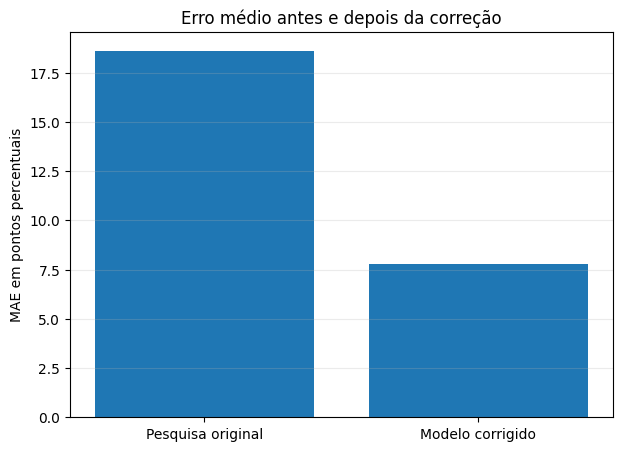

In [17]:
# ======================================
# GRÁFICO DO ERRO ANTES E DEPOIS DA CORREÇÃO
# ======================================

# Cria a área do gráfico.
plt.figure(figsize=(7, 5))

# Nomes das duas abordagens que serão comparadas no eixo horizontal.
nomes = ["Pesquisa original", "Modelo corrigido"]

# Valores do MAE convertidos para pontos percentuais.
valores = [mae_bruto * 100, mae_corrigido * 100]

# O gráfico de barras é adequado porque estamos comparando duas categorias independentes.
plt.bar(nomes, valores)

# Identifica a unidade do eixo vertical.
plt.ylabel("MAE em pontos percentuais")

# Título explica a mensagem principal do gráfico.
plt.title("Erro médio antes e depois da correção")

# A grade horizontal facilita a comparação das alturas das barras.
plt.grid(axis="y", alpha=0.25)

# Exibe o gráfico.
plt.show()


In [18]:
# ======================================
# ANÁLISE DO ERRO POR ESTADO
# ======================================

# Seleciona somente as colunas necessárias para comparar os erros estaduais.
# .copy() evita modificar acidentalmente o DataFrame principal nesta etapa.
comparacao = df[[
    "state",
    "poll_rep_share_1936",
    "corrected_rep_share_1936",
    "actual_rep_share_1936"
]].copy()

# Calcula o erro absoluto da pesquisa original em cada estado.
# Multiplicamos por 100 para expressar o resultado em pontos percentuais.
comparacao["erro_original_pp"] = (
    (comparacao["poll_rep_share_1936"] - comparacao["actual_rep_share_1936"]).abs() * 100
)

# Calcula o erro absoluto do modelo corrigido em cada estado.
comparacao["erro_corrigido_pp"] = (
    (comparacao["corrected_rep_share_1936"] - comparacao["actual_rep_share_1936"]).abs() * 100
)

# Ordena os estados do maior para o menor erro original.
# Isso ajuda a identificar onde a Literary Digest errou mais e verificar se a correção ajudou nesses casos.
comparacao = comparacao.sort_values("erro_original_pp", ascending=False)

# Exibe os 15 estados com maior erro na previsão original.
display(comparacao.head(15))


,state,poll_rep_share_1936,corrected_rep_share_1936,actual_rep_share_1936,erro_original_pp,erro_corrigido_pp
18,Massachusetts,0.7711,0.5878,0.4491,32.1928,13.8625
36,Rhode Island,0.7488,0.5716,0.4307,31.8070,14.0862
46,Wisconsin,0.6192,0.4775,0.3217,29.7539,15.5831
27,New Jersey,0.6799,0.5215,0.3993,28.0602,12.2286
26,New Hampshire,0.7708,0.5876,0.4910,27.9805,9.6560
23,Montana,0.5576,0.4328,0.2848,27.2800,14.7972
44,Washington,0.5828,0.4510,0.3104,27.2336,14.0620
1,Arizona,0.5420,0.4214,0.2782,26.3727,14.3186
20,Minnesota,0.5974,0.4617,0.3340,26.3374,12.7655
5,Connecticut,0.6823,0.5233,0.4217,26.0592,10.1600
